<a href="https://www.kaggle.com/code/lalit7881/predicting-irrigation-need-xgb?scriptVersionId=311529201" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
from scipy.special import logit
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


## Loading dataset

In [2]:
SEED = 42
data_dir = Path("/kaggle/input/competitions/playground-series-s6e4")
train_df = pd.read_csv(data_dir / "train.csv")
test_df  = pd.read_csv(data_dir / "test.csv")

## Train-test

In [3]:
TARGET = "Irrigation_Need"
X_train = train_df.drop(columns=["id", TARGET]).copy()
y_train = train_df[TARGET].copy()
y_train = y_train.map({"Low": 0, "Medium": 1, "High": 2})

X_test = test_df.drop(columns=["id"])

y_train

0         0
1         0
2         0
3         1
4         0
         ..
629995    1
629996    1
629997    2
629998    0
629999    0
Name: Irrigation_Need, Length: 630000, dtype: int64

In [4]:
train_df.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [6]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [7]:
train_df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [8]:
train_df.duplicated().sum()

np.int64(0)

## EDA

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1            6.98  ...      Wheat        Vegetative  Kharif         Rainfed   

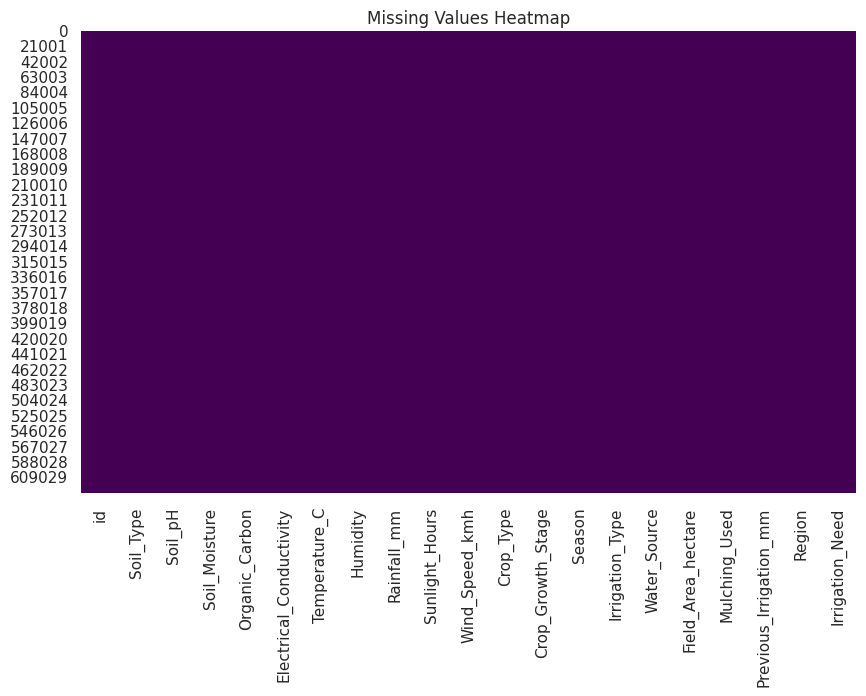

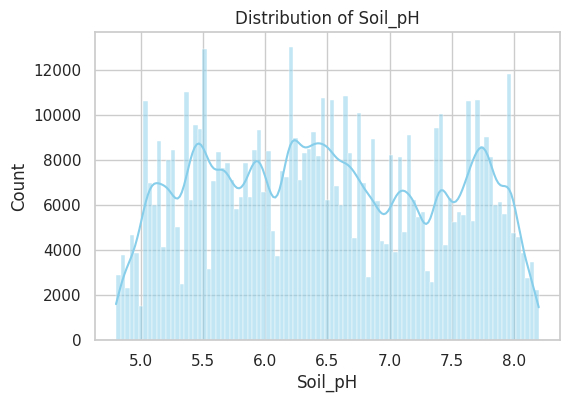

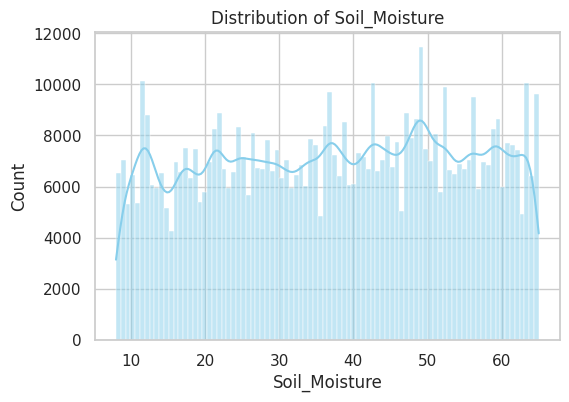

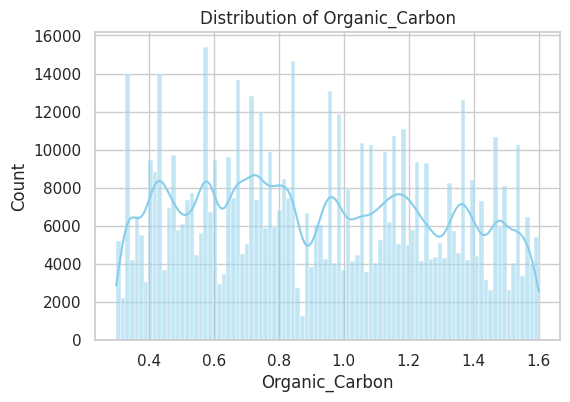

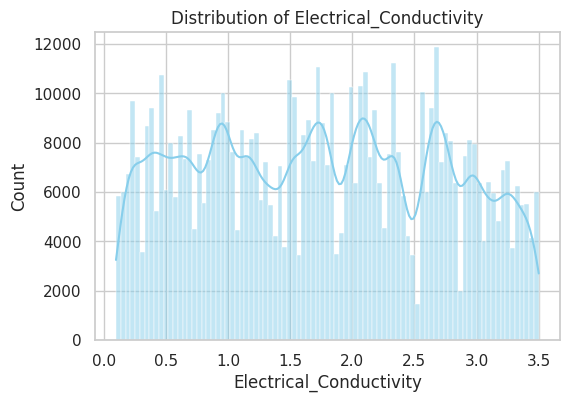

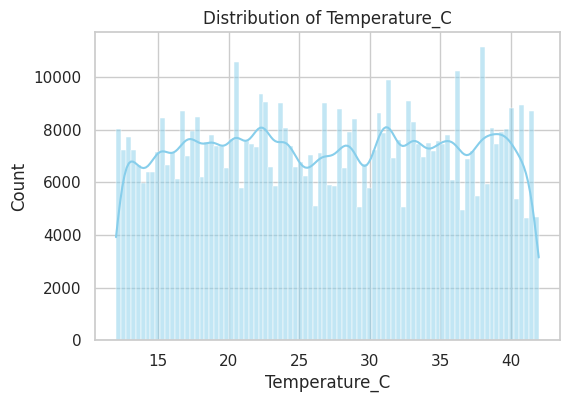

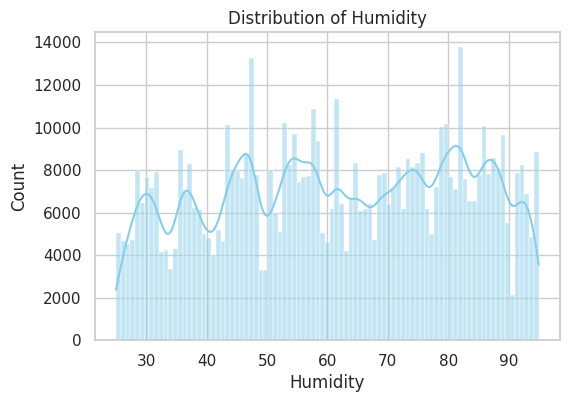

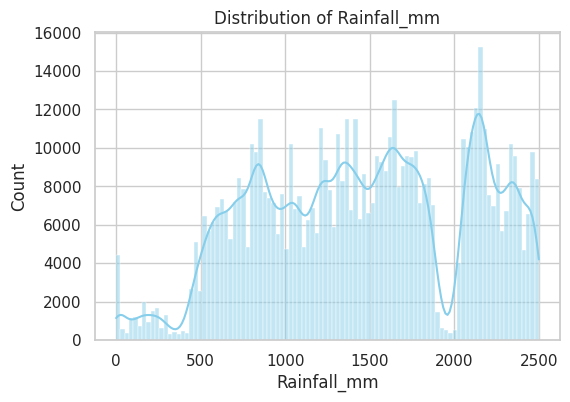

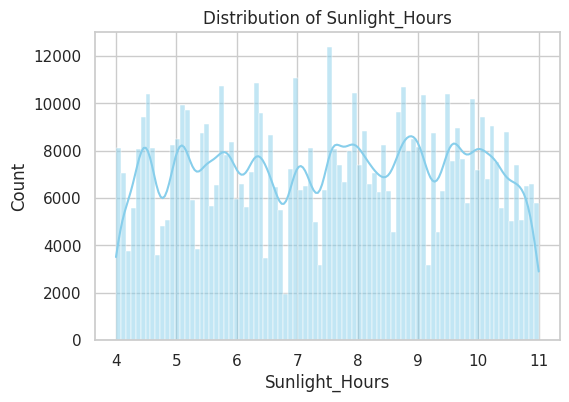

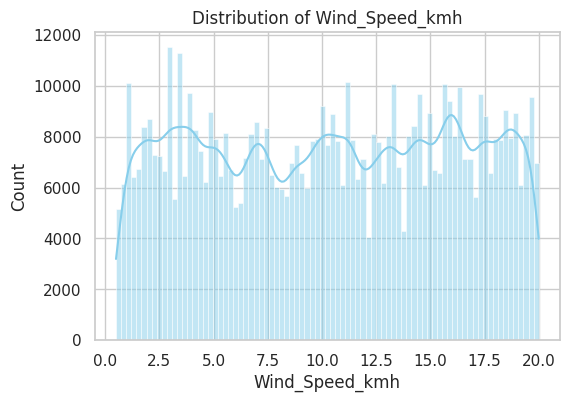

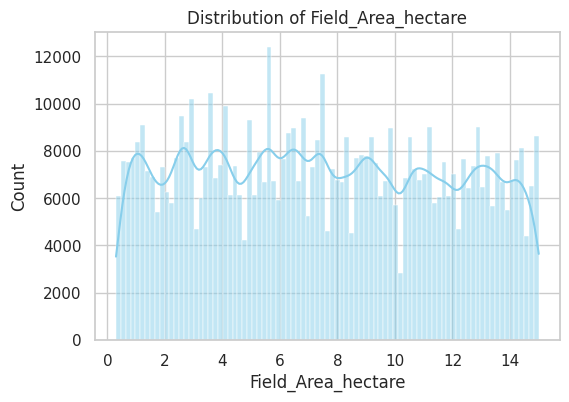

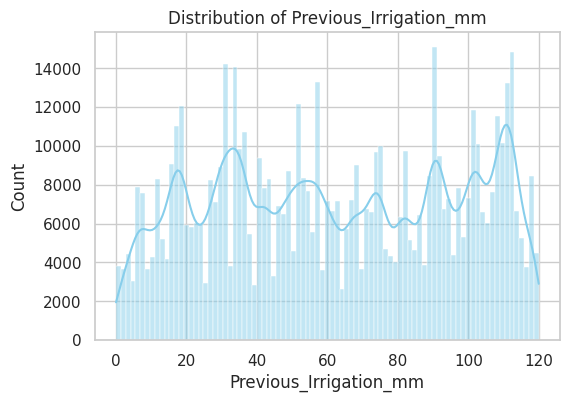

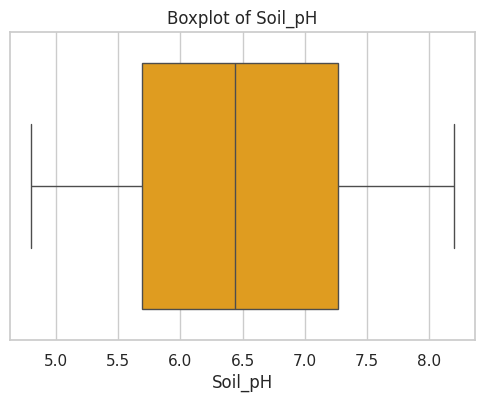

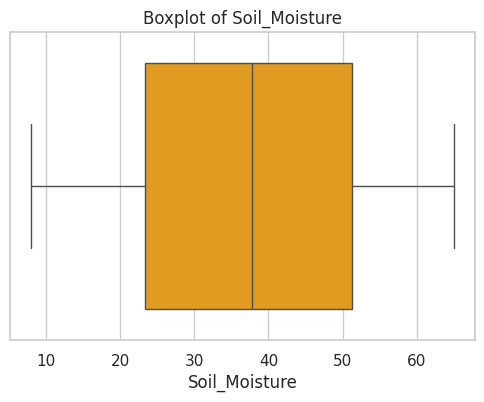

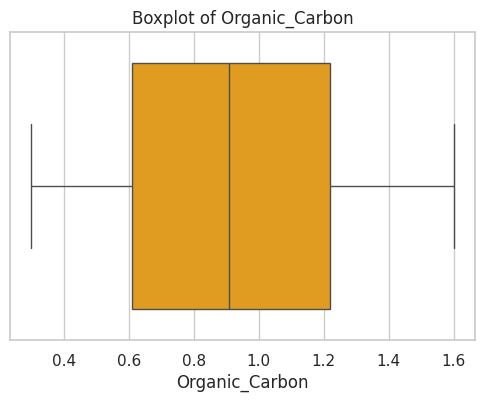

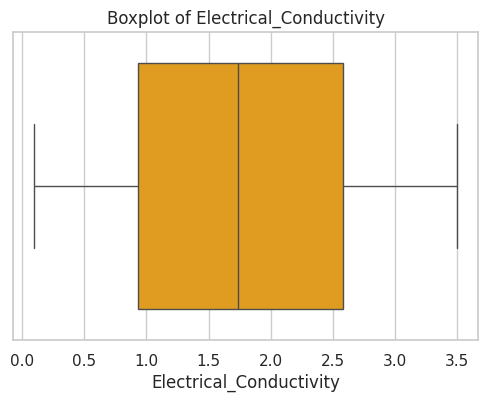

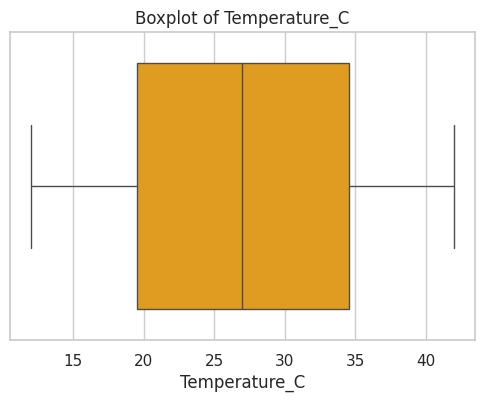

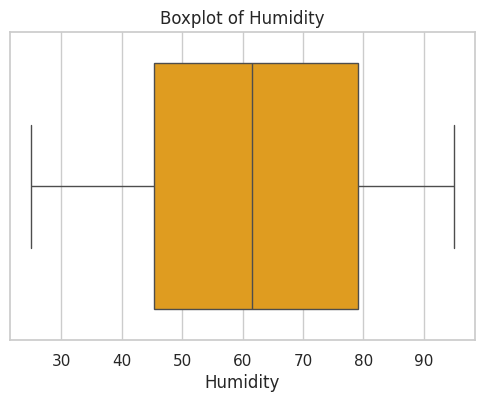

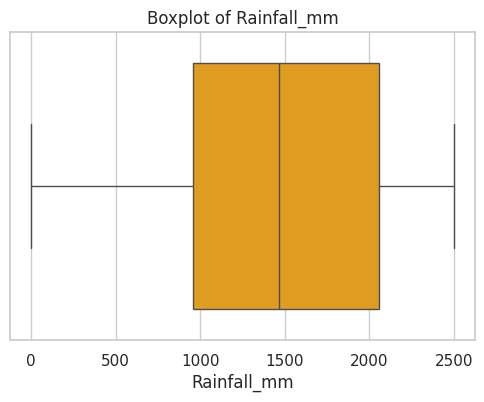

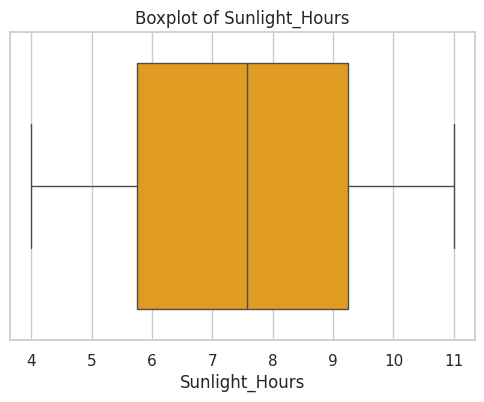

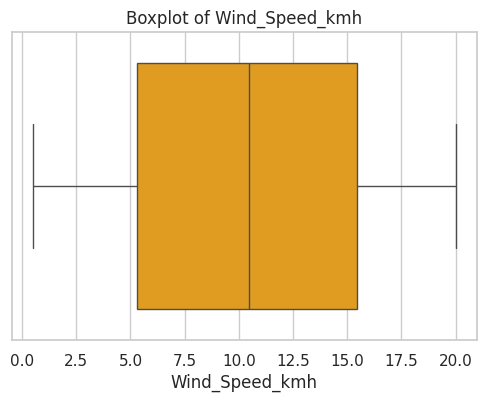

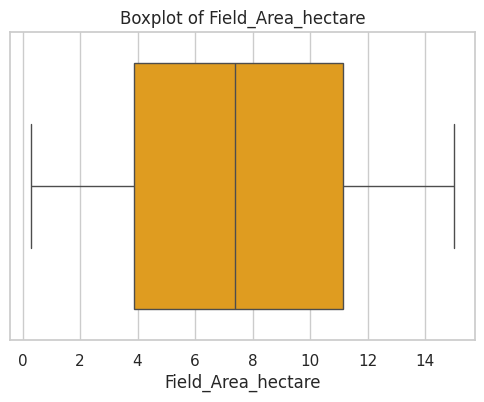

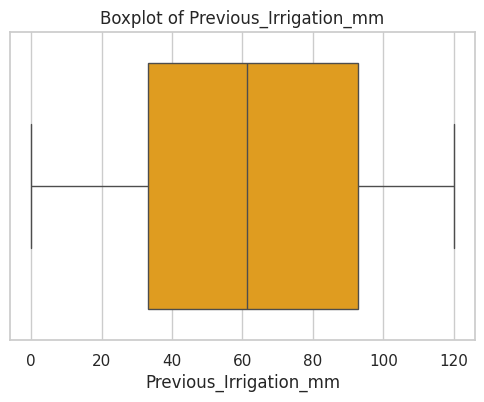

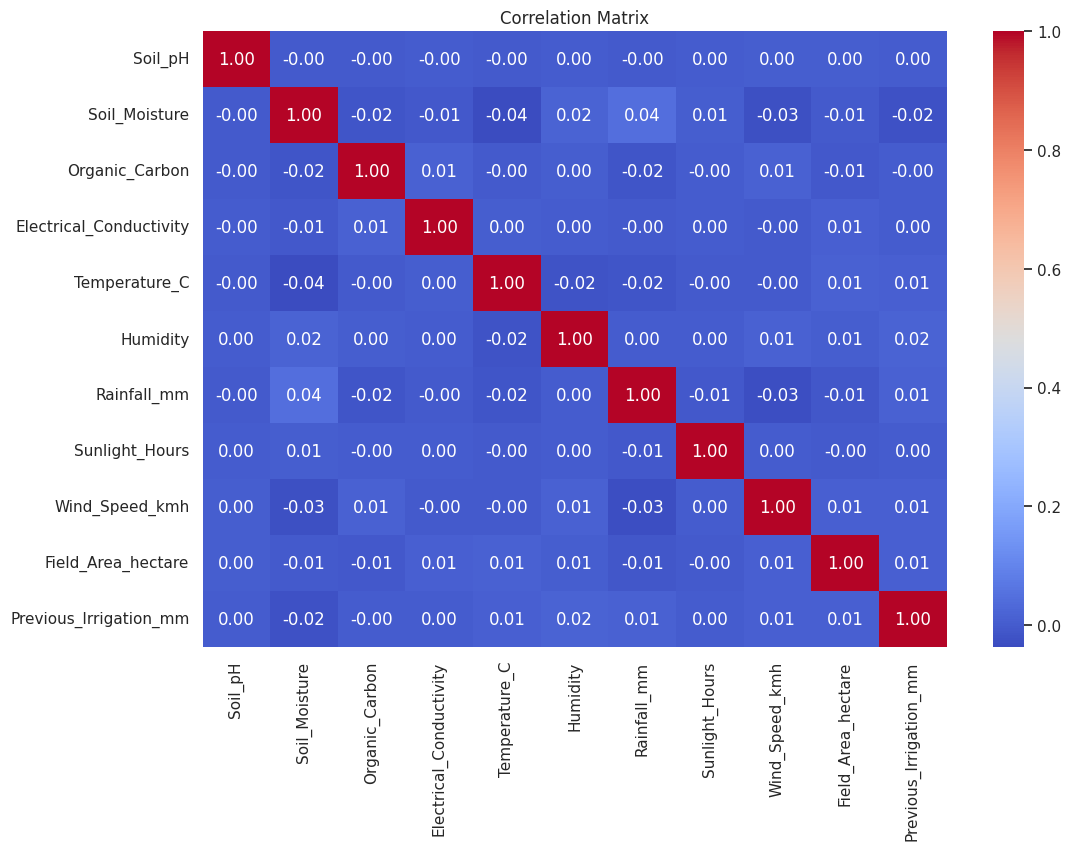

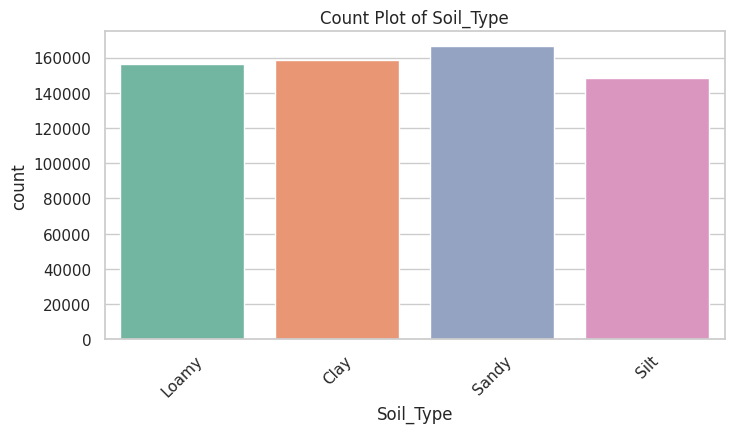

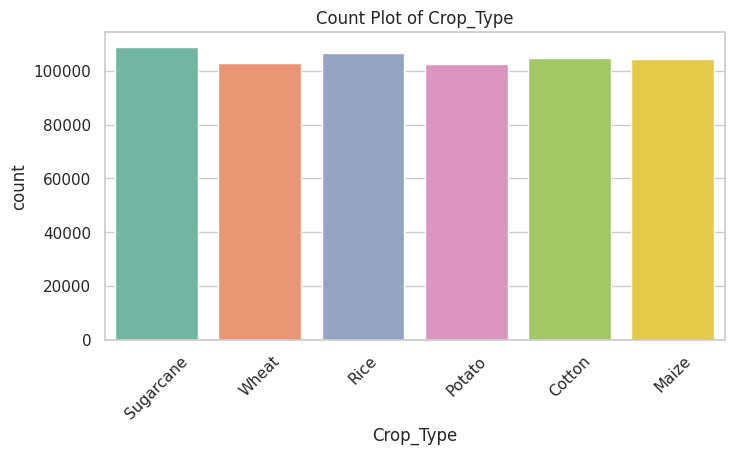

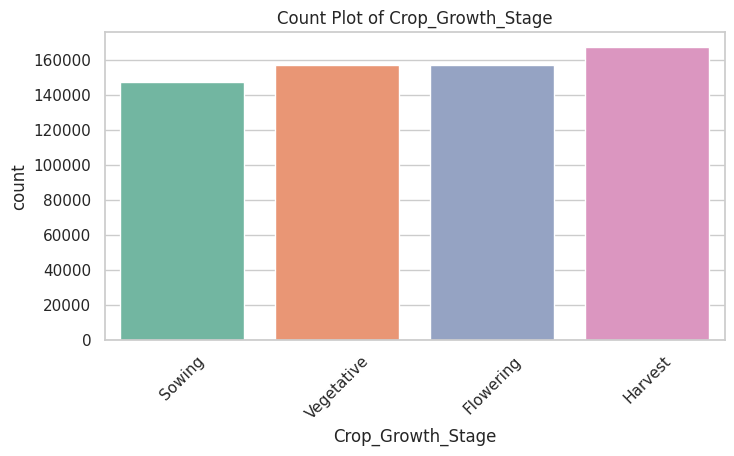

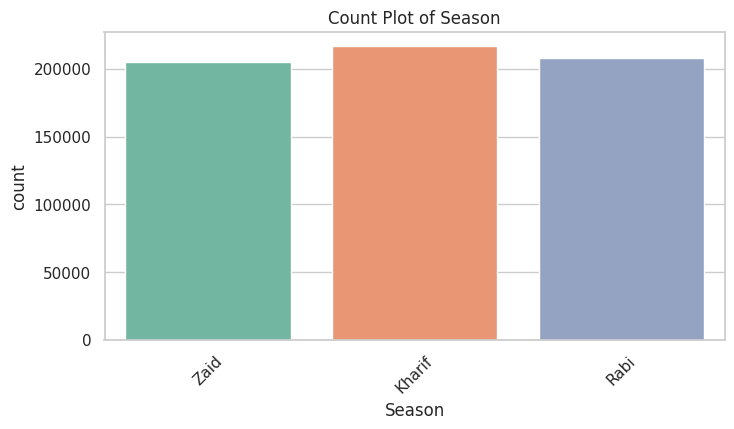

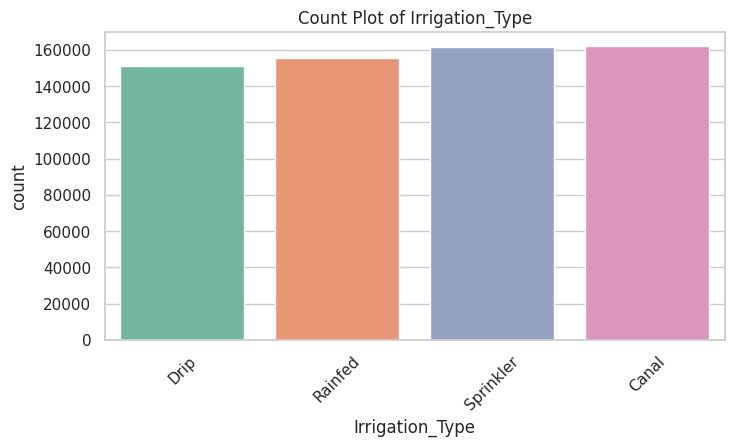

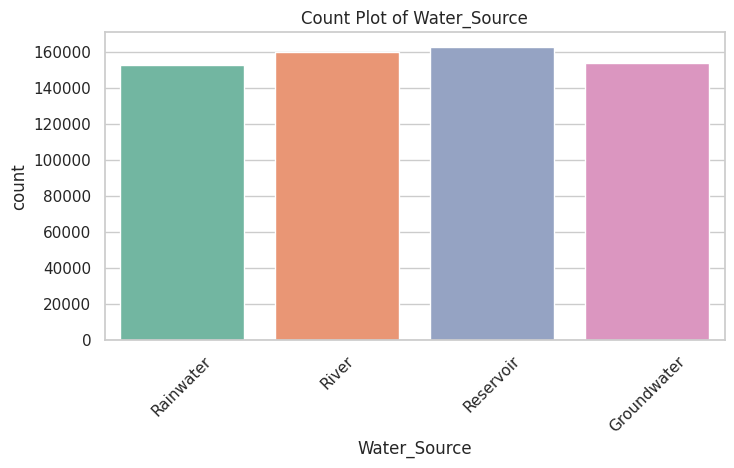

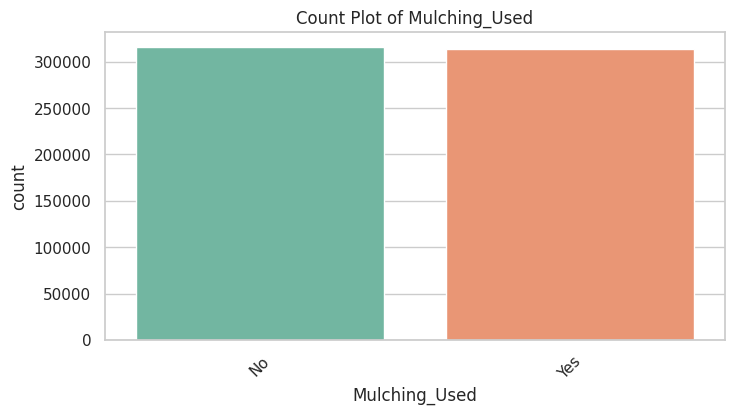

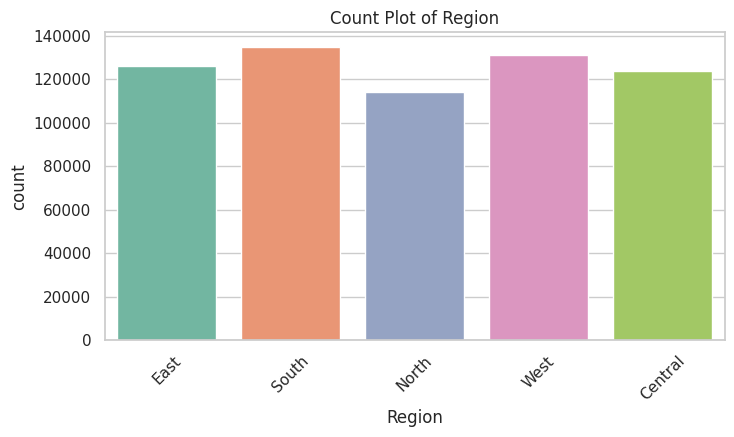

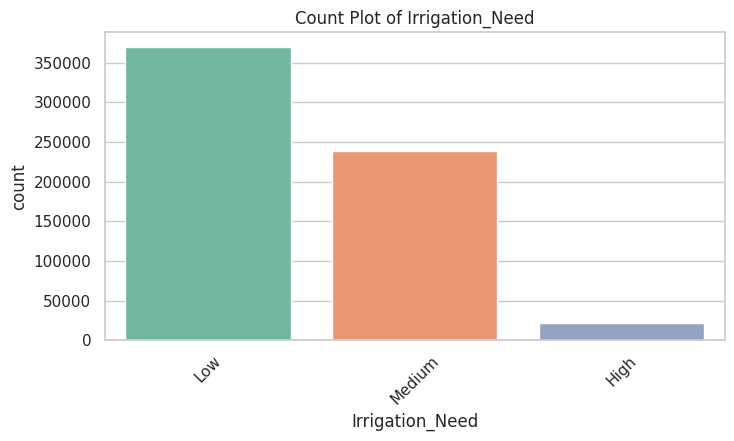

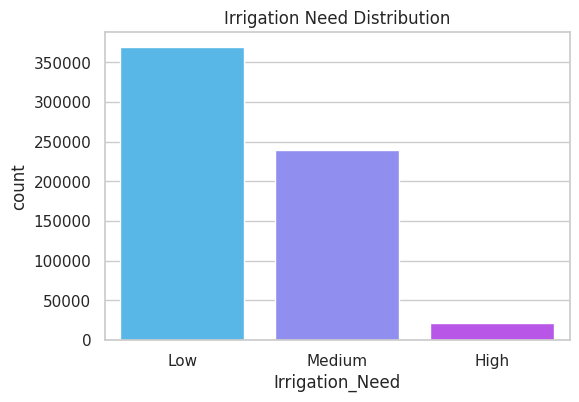

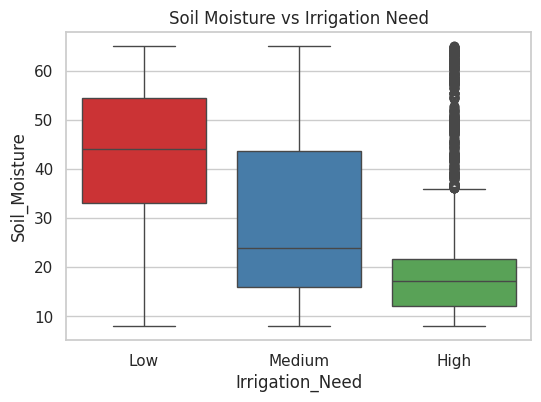

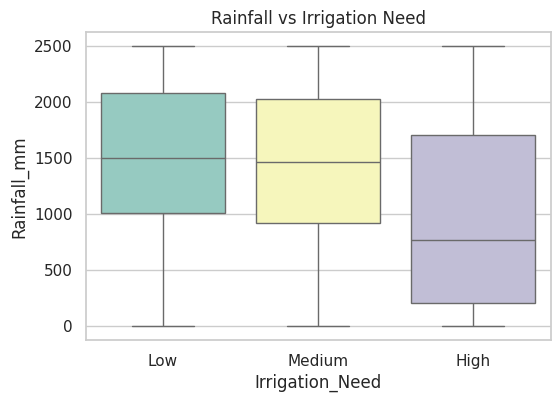

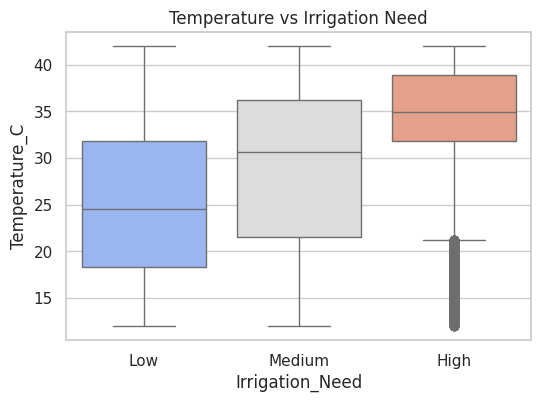

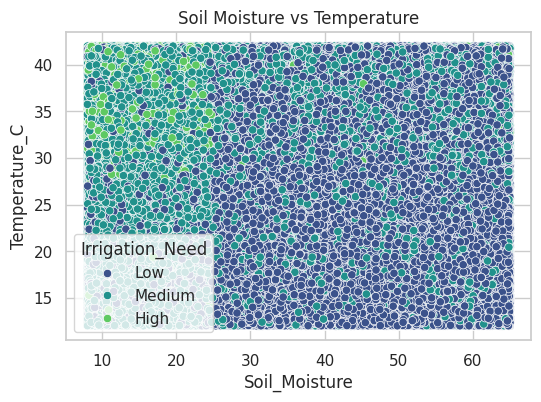

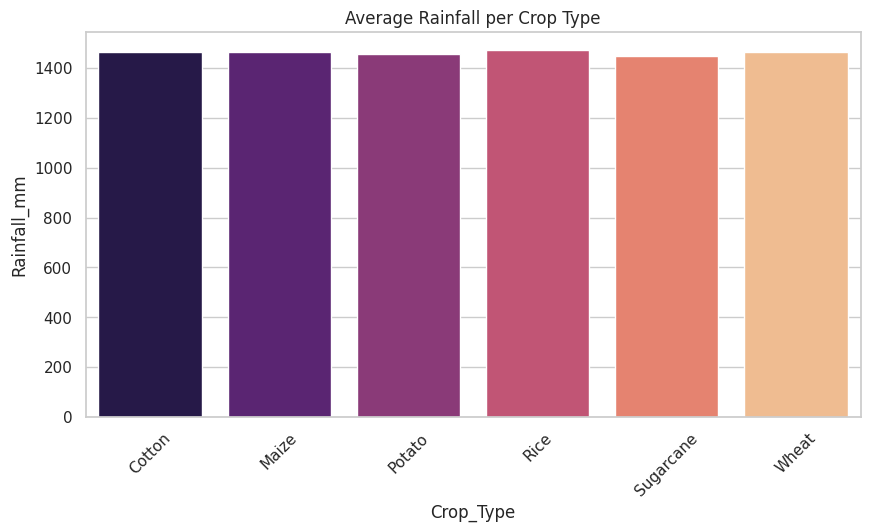

In [9]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. LOAD DATA
# ==============================
# Example:
# train_df = pd.read_csv("your_dataset.csv")

# ==============================
# 3. BASIC INFO
# ==============================
print(train_df.head())
print(train_df.info())

# ==============================
# 4. MISSING VALUES HEATMAP
# ==============================
plt.figure(figsize=(10,6))
sns.heatmap(train_df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ==============================
# 5. DISTRIBUTION PLOTS
# ==============================
num_cols = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C',
    'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare',
    'Previous_Irrigation_mm'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(train_df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

# ==============================
# 6. BOXPLOTS
# ==============================
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train_df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.show()

# ==============================
# 7. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(12,8))
corr = train_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 8. COUNT PLOTS
# ==============================
cat_cols = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region', 'Irrigation_Need'
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=train_df, x=col, palette='Set2')
    plt.xticks(rotation=45)
    plt.title(f'Count Plot of {col}')
    plt.show()

# ==============================
# 9. TARGET VARIABLE
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Irrigation_Need', palette='cool')
plt.title("Irrigation Need Distribution")
plt.show()

# ==============================
# 10. RELATIONSHIP ANALYSIS
# ==============================

plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x='Irrigation_Need', y='Soil_Moisture', palette='Set1')
plt.title("Soil Moisture vs Irrigation Need")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x='Irrigation_Need', y='Rainfall_mm', palette='Set3')
plt.title("Rainfall vs Irrigation Need")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x='Irrigation_Need', y='Temperature_C', palette='coolwarm')
plt.title("Temperature vs Irrigation Need")
plt.show()

# ==============================
# 11. SCATTER PLOT
# ==============================
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=train_df,
    x='Soil_Moisture',
    y='Temperature_C',
    hue='Irrigation_Need',
    palette='viridis'
)
plt.title("Soil Moisture vs Temperature")
plt.show()



# ==============================
# 12. BAR PLOT (BUSINESS INSIGHT)
# ==============================
avg_rainfall = train_df.groupby('Crop_Type')['Rainfall_mm'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=avg_rainfall,
    x='Crop_Type',
    y='Rainfall_mm',
    palette='magma'
)
plt.xticks(rotation=45)
plt.title("Average Rainfall per Crop Type")
plt.show()

In [10]:
X_train.isna().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

In [11]:
cat_cols = [col for col in X_train.select_dtypes(include=["object"])]
for col in cat_cols:
    print(f"{col:<20}: {X_train[col].unique()}")

Soil_Type           : ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type           : ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage   : ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season              : ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type     : ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source        : ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used       : ['No' 'Yes']
Region              : ['East' 'South' 'North' 'West' 'Central']


In [12]:
num_cols = [col for col in X_train.select_dtypes(exclude=["object"])]

X_train[num_cols].describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [13]:
def scale(X_tr, X_val, X_test):
    scaler = StandardScaler()
    X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
    X_val[num_cols] = scaler.transform(X_val[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

## One hot encoding

In [14]:
def onehot_encode(X_tr, X_val, X_test):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    tr_oh = encoder.fit_transform(X_tr[cat_cols])
    val_oh = encoder.transform(X_val[cat_cols])
    test_oh = encoder.transform(X_test[cat_cols])
    
    X_tr.drop(columns=cat_cols, inplace=True)
    X_val.drop(columns=cat_cols, inplace=True)
    X_test.drop(columns=cat_cols, inplace=True)
    
    X_tr[encoder.get_feature_names_out(cat_cols)] = tr_oh.astype("int")
    X_val[encoder.get_feature_names_out(cat_cols)] = val_oh.astype("int")
    X_test[encoder.get_feature_names_out(cat_cols)] = test_oh.astype("int")

### XGB 

In [15]:
xgb_params = {
    'learning_rate': 0.03, 
    'max_depth': 4, 
    'min_child_weight': 2,
    'subsample': 0.98,
    'gamma': 4.2, 
    'colsample_bytree': 0.5, 
    'lambda': 0.001,
    'alpha': 4.1,
    'n_estimators': 50_000, 
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'device': 'cuda',
}

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
bas_scores = []
n_classes = y_train.nunique()
oof_probs = np.zeros((len(X_train), n_classes))
oof_test = np.zeros((len(X_test), n_classes))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr = X_train.iloc[tr_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    scale(X_tr, X_val, X_te)
    onehot_encode(X_tr, X_val, X_te)

    sw = compute_sample_weight(class_weight="balanced", y=y_tr)
    
    model = XGBClassifier(
        **xgb_params,
        random_state=SEED+fold,
        callbacks=[
            xgb.callback.EarlyStopping(
                rounds=200,
                save_best=True
            )
        ]
    )

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sw,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    oof_probs[val_idx] = model.predict_proba(X_val)
    
    test_probs = model.predict_proba(X_te)
    oof_test += test_probs / skf.n_splits

    bas = balanced_accuracy_score(y_val, preds)
    bas_scores.append(bas)
    print(f"Fold {fold+1} BAS: {bas}")
print(f"Mean BAS: {np.mean(bas_scores)}")

Fold 1 BAS: 0.9703129695917522
Fold 2 BAS: 0.9730259007604722
Fold 3 BAS: 0.9725691388165428
Fold 4 BAS: 0.9718168800454515
Fold 5 BAS: 0.9709301065888476
Mean BAS: 0.9717309991606132


### Baseline

In [17]:
bas_baseline = balanced_accuracy_score(y_train, oof_probs.argmax(axis=1))

def tune_preds(probs, bias):
    tuned = logit(np.clip(probs, 1e-15, 1 - 1e-15)) + bias
    return tuned.argmax(axis=1)

best_bias = np.zeros(3)
best_score = bas_baseline

for step in [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]:
    improved = True
    while improved:
        improved = False
        for b_idx in range(3):
            for d in [1, -1]:
                trial = best_bias.copy()
                trial[b_idx] += d * step

                bas = balanced_accuracy_score(y_train, tune_preds(oof_probs, trial))

                if bas > best_score:
                    best_score = bas
                    best_bias = trial
                    improved = True

print(f"Found best bias: {best_bias}")
print(f"Final BAS score: {best_score}")

Found best bias: [-0.34 -0.92  0.  ]
Final BAS score: 0.972824849507103


## Submission file

In [18]:
test_preds = tune_preds(oof_test, best_bias)
preds = pd.Series(test_preds).map({0: "Low", 1: "Medium", 2: "High"})

submission = pd.DataFrame({
    "id": test_df["id"],
    TARGET: preds
})

submission.to_csv("submission.csv", index=False)

## Thank you..pls upvote!!!!!!!!!